In [1]:
import joblib, pandas as pd, numpy as np

from utils.narrative_profiles_optimization_utils import (
    optimise,                      # GA / NSGA-II
    plot_best_features, 
    plot_pareto             # nice bar-chart of the optimum
)
import joblib, pandas as pd
import os
from pathlib import Path

In [2]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
TRAINED_MODELS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
model_file_name = "xgb_pipeline_5.1_narrative_profiles.pkl"
MODEL_PATH = os.path.join(TRAINED_MODELS_DIR, model_file_name)
TRAINED_MODELS_DIR = Path(TRAINED_MODELS_DIR)

In [3]:

# -----------------------------------------------------------------
#  Your trained model and a reference feature matrix
#  ---------------------------------------------------------------
pipeline = joblib.load(MODEL_PATH)   # your trained Pipeline
full_df= pd.read_parquet(TRAINED_MODELS_DIR/"xgb_pipeline_5.1_narrative_profiles_training_df_cleaned.parquet")

In [4]:

# feature columns = whatever the pipeline saw during fit
feature_cols = pipeline.feature_names_in_.tolist()
X_ref        = full_df[feature_cols]

# metrics (must match model's prediction order)
train_metrics = [
    "production_total",
    "emission_total",
    "technical_cost",
    "emission_avg_last_five_years",
]


# Regret and Utopia-Dystopia Matrix 

## narrative definitions

In [5]:
# metric  →  optimisation goal
narratives_cfg = {
    "EnergyLeader"     : dict(metric="production_total", sense="max"),
    "EmissionsReduction": dict(metric="emission_total",   sense="min"),
    "LowCost"          : dict(metric="technical_cost",    sense="min"),
}


## Run the optimizer for each narrative

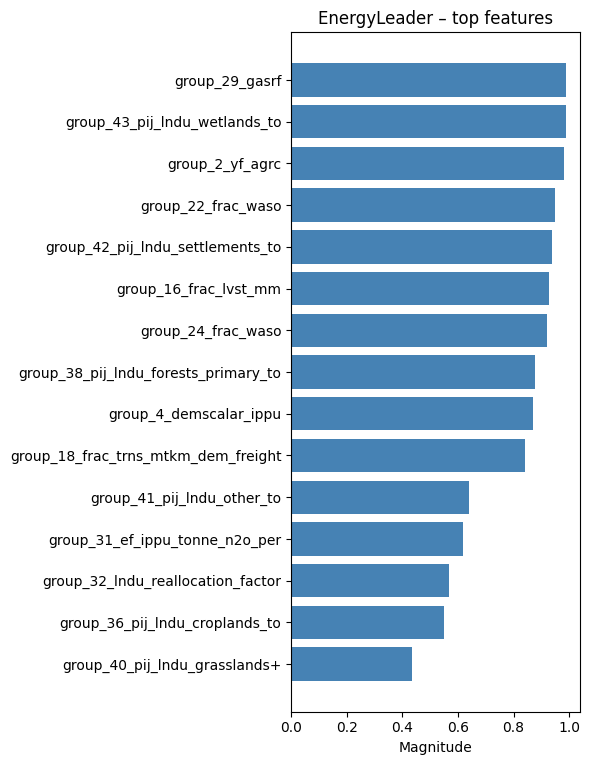

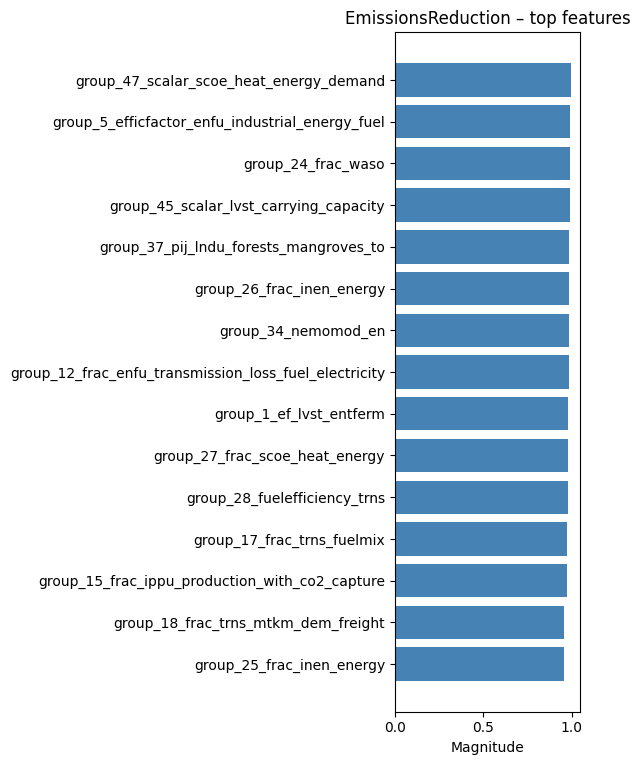

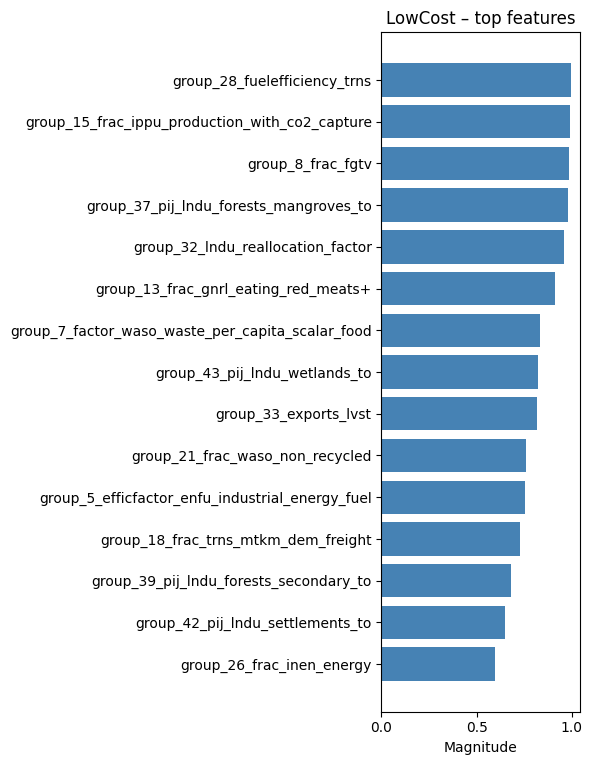

In [6]:
# ---------------------------------------------------------------------------
# Run the updated `optimise` for every narrative and collect results
# ---------------------------------------------------------------------------
solutions = {}          # narrative → Series of best feature values
scores    = {}          # narrative → Series of all predicted metrics
utopias   = {}          # narrative → scalar utopia value (its own metric)

for name, cfg in narratives_cfg.items():

    # single-objective search (GA + optional L-BFGS)
    best_x, best_val = optimise(
        pipeline,
        X_ref=X_ref,
        train_targets=train_metrics,
        targets=cfg["metric"],          # one metric
        goals=cfg["sense"],             # "max" or "min"
        n_gen=120,
        pop_size=300,
    )

    # store the policy and its headline score
    solutions[name] = best_x
    utopias[name]   = best_val

    # predict *all* metrics for this policy
    pred_all = pipeline.predict(best_x.to_frame().T).ravel()
    scores[name] = pd.Series(pred_all, index=train_metrics)

    # quick visual of the knob settings
    plot_best_features(best_x, top_n=15, title=f"{name} – top features")


### How we evaluate one narrative-optimized policy in another narrative’s metric

1. **Start with the feature vector** that was optimised for *Narrative A*.

2. **Pass that vector through the trained pipeline**  
   → you obtain predicted values for **all** metrics (energy, emissions, cost).

3. **Select the metric that Narrative B cares about**.

4. **Compute regret vs Narrative B’s utopia**  
   * **Absolute:**  
     `regret_abs = utopia_B − achieved`  
     (flip sign if the goal is “minimize”).
   * **Percent-of-utopia:**  
     `regret_pct = regret_abs / |utopia_B|`
   * **Range-normalised:**  
     `regret_range = regret_abs / (utopia_B − worst_B)`  
     where `worst_B` is the worst (or 95 th/5 th percentile) value observed.

5. **Write the result into the table**  
   *Row =* Policy from A”, *Column =* “Evaluated as B”.

Repeat for every (policy × narrative) pair to fill the three regret
matrices. This shows, for example, how the **Energy-Leader policy** fares
when judged by **emissions** or **cost**, and vice-versa.

## Collect the “utopia” (best metric value) for each narrative

In [7]:
# ------------------------------------------------------------
# Utopia values keyed by narrative name
# ------------------------------------------------------------
utopia_vals = {
    n: scores[n][cfg["metric"]]        # scores row → pick its own metric
    for n, cfg in narratives_cfg.items()
}



## Regret helper

In [8]:
###############################################################################
# 4.  Regret helpers
###############################################################################

# ---------------------------------------------------------
# absolute regret stays the same
# ---------------------------------------------------------
def regret_abs(achieved, utopia, goal):
    return utopia - achieved if goal == "max" else achieved - utopia

# ---------------------------------------------------------
# %-of-utopia normalisation
# ---------------------------------------------------------
def regret_pct_utopia(achieved, utopia, goal):
    ra = regret_abs(achieved, utopia, goal)
    return ra / abs(utopia)            # sign preserved

# ---------------------------------------------------------
# min-max (range) normalisation   – needs a 'worst' value
# ---------------------------------------------------------
# ---------------- range-normalised regret -----------------
def regret_range(achieved, utopia, worst, goal):
    ra = regret_abs(achieved, utopia, goal)
    span = (utopia - worst) if goal == "max" else (worst - utopia)
    if span == 0:
        return 0.0                    # no range -> zero regret
    return ra / span



## Build the regret matrix

In [10]:
###############################################################################
# 5.  Build absolute & proportional regret matrices
###############################################################################
rows_abs, rows_pct, rows_rng = [], [], []

# pre-compute a 'worst' (dystopia) value for each metric
# choose a worst that is guaranteed to be worse than that utopia
# predict the model on every row of the original feature set
pred_all = pipeline.predict(X_ref)                 # shape (n_rows, n_metrics)
pred_all = pd.DataFrame(pred_all, columns=train_metrics)

# build worst according to each narrative’s goal, but *in model space*
worst_vals = {}
for name, cfg in narratives_cfg.items():
    m, sense = cfg["metric"], cfg["sense"]
    if sense == "max":
        worst_vals[m] = pred_all[m].min()          # smallest model prediction
    else:  # "min"
        worst_vals[m] = pred_all[m].max()          # largest model prediction



for src_name, src_vect in scores.items():
    for eval_name, eval_cfg in narratives_cfg.items():
        metric, goal = eval_cfg["metric"], eval_cfg["sense"]
        achieved = src_vect[metric]
        utopia   = utopia_vals[eval_name]      # <-- use dict, not scalar
        worst    = worst_vals[metric]

        rows_abs.append(dict(Policy=src_name, Evaluated_as=eval_name,
                             Regret=regret_abs(achieved, utopia, goal)))
        rows_pct.append(dict(Policy=src_name, Evaluated_as=eval_name,
                             Regret=regret_pct_utopia(achieved, utopia, goal)))
        rows_rng.append(dict(Policy=src_name, Evaluated_as=eval_name,
                             Regret=regret_range(achieved, utopia, worst, goal)))

reg_abs =  pd.DataFrame(rows_abs ).pivot(index="Policy", columns="Evaluated_as", values="Regret")
reg_pct =  pd.DataFrame(rows_pct ).pivot(index="Policy", columns="Evaluated_as", values="Regret")
reg_rng =  pd.DataFrame(rows_rng ).pivot(index="Policy", columns="Evaluated_as", values="Regret")




## Display neat summary

In [11]:
# ------------------------------------------------------------
# Units for pretty formatting
# ------------------------------------------------------------
units = {
    "production_total": " PJ",
    "emission_total":   " tCO₂e",
    "technical_cost":   " Million $",
}

# ------------------------------------------------------------
# Formatting dictionaries
# ------------------------------------------------------------
fmt_abs = {
    n: "{:+,.0f}" + units[narratives_cfg[n]["metric"]]
    for n in reg_abs.columns          # n = narrative name
}

fmt_pct = {n: "{:+.1%}" for n in reg_pct.columns}
fmt_rng = {n: "{:+.1%}" for n in reg_rng.columns}

print("\n### ABSOLUTE regret")
display(reg_abs.style.format(fmt_abs).background_gradient(cmap="Reds"))

print("\n### PROPORTIONAL regret (vs utopia %)")
display(reg_pct.style.format(fmt_pct).background_gradient(cmap="Oranges"))

print("\n### RANGE-NORMALISED regret (0–100 % of utopia-worst window)")
display(reg_rng.style.format(fmt_rng).background_gradient(cmap="Purples"))



### ABSOLUTE regret


Evaluated_as,EmissionsReduction,EnergyLeader,LowCost
Policy,,,
EmissionsReduction,+0 tCO₂e,"+2,543 PJ",+3 Million $
EnergyLeader,+162 tCO₂e,+0 PJ,+10 Million $
LowCost,+100 tCO₂e,"+1,040 PJ",+0 Million $



### PROPORTIONAL regret (vs utopia %)


Evaluated_as,EmissionsReduction,EnergyLeader,LowCost
Policy,,,
EmissionsReduction,+0.0%,+57.4%,+23.7%
EnergyLeader,+373.1%,+0.0%,+84.2%
LowCost,+231.6%,+23.5%,+0.0%



### RANGE-NORMALISED regret (0–100 % of utopia-worst window)


Evaluated_as,EmissionsReduction,EnergyLeader,LowCost
Policy,,,
EmissionsReduction,+0.0%,+117.5%,+26.0%
EnergyLeader,+115.9%,+0.0%,+92.2%
LowCost,+71.9%,+48.0%,+0.0%


- **Emissions-Reduction optimal policy** –  
  Meets its own emissions utopia **(+0 t CO₂e)**; but gives up **2 500 PJ of energy**  
  (≈ 57 % below the energy utopia, **118 % on the 0–100 scale – 18 % worse than the model’s worst energy**)  
  and adds **≈ $3 M** to cost (≈ 24 % below the cost utopia, **26 % on the scale – one-quarter of the way to the model’s worst cost**).

- **Energy-Leader optimal policy** –  
  Reaches the energy utopia **(+0 PJ)**; yet adds **+162 t CO₂e**  
  (≈ 373 % over the emissions utopia, **116 % on the scale – 16 % beyond the model’s worst emissions**)  
  and **≈ $10 M** extra cost (≈ 84 % over the cost utopia, **92 % on the scale – close to the model’s worst cost**).

- **Low-Cost optimal policy** –  
  Holds cost at the utopia **(+$0 M)**; sacrifices **1 040 PJ of energy**  
  (≈ 24 % below the energy utopia, **48 % on the scale – about halfway to the worst energy**)  
  and raises emissions by **+100 t CO₂e** (≈ 232 % over the emissions utopia, **72 % on the scale – roughly three-quarters of the way to the worst emissions**).


In [14]:
###############################################################################
# Full comparison – every policy’s WORST and MEAN range-regret
#   • lower values = better
#   • lowest in each column highlighted green
###############################################################################

tbl = reg_rng                    # 0–100 % range-normalised regrets

# 1) compute summary stats
summary = pd.DataFrame({
    "WorstRegret": tbl.max(axis=1),
    "MeanRegret":  tbl.mean(axis=1),
}).round(2)                      # keep two decimals

# 2) styling helper: colour the minimum of each column in green
def highlight_min(s):
    is_min = s == s.min()
    return ['background-color: mediumseagreen; color: white' if v else '' for v in is_min]

# 3) display
display(
    summary.style
           .format("{:.1%}")                     # show as %
           .apply(highlight_min, subset=["WorstRegret", "MeanRegret"])
           .background_gradient(cmap="OrRd")     # overall heat-map (red = worse)
           .set_caption("Range-normalised regret  (0 % = utopia, 100 % = model worst)")
)



,WorstRegret,MeanRegret
Policy,,
EmissionsReduction,118.0%,48.0%
EnergyLeader,116.0%,69.0%
LowCost,72.0%,40.0%


# Areas of agreement 

### Finding “areas of agreement” 

1. **Optimise for all three metrics at once**  
   Run NSGA-II to explore the design space.  From the last generation keep only the **non-dominated** solutions – the true Pareto front.  
   *Outputs*: `pareto_X` (feature settings) and `pareto_F` (the surrogate’s predicted metrics).

2. **Set the reference points for each narrative**  
   *Utopia*  = the metric value returned by that narrative’s own single-objective optimiser.  
   *Worst*   = the **worst value the surrogate ever predicts** for that metric (min for “max” goals, max for “min” goals) – ensures utopia is always better than worst in model space.

3. **Compute range-normalised regret** for every Pareto policy and every narrative  

   $$
   r \;=\; \frac{\lvert \text{utopia} - \text{achieved} \rvert}
                {\lvert \text{utopia} - \text{worst} \rvert}
   $$

   *Scale*: 0 % = matches utopia, 100 % = as poor as the model’s worst prediction, >100 % = even worse.

4. **Filter for consensus**  
   Keep policies whose largest regret across narratives is ≤ a chosen cut-off  
   (e.g. 0.80 → every narrative loses no more than 80 % of its achievable performance).

5. **Visualise the agreement cloud**  
   Plot those low-regret policies (`plot_pareto(agree_F)`) in metric space to see the region where all narratives can accept the outcome.

*Result*: a compact set of policies that satisfy every narrative within the specified performance loss threshold.




In [17]:
###############################################################################
# Areas of agreement – **updated workflow**
#   • Worst values now come from the model’s own predictions, not raw data
#   • Uses the new `optimise` that includes multi-seed GA and optional BFGS
###############################################################################

# ---------------------------------------------------------------------------
# 1.  Multi-objective search  → true Pareto front
# ---------------------------------------------------------------------------
raw_X, raw_F = optimise(
    pipeline, X_ref,
    train_targets=train_metrics,
    targets=["production_total", "emission_total", "technical_cost"],
    goals   =["max",             "min",            "min"],
    n_gen=200, pop_size=400,
)
print("Last generation:", len(raw_X), "policies")

# keep only the non-dominated solutions
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
idx_nd = NonDominatedSorting().do(raw_F.values, only_non_dominated_front=True)

pareto_X = raw_X.iloc[idx_nd].reset_index(drop=True)
pareto_F = raw_F.iloc[idx_nd].reset_index(drop=True)
print("True Pareto front:", len(pareto_X), "policies")

Last generation: 768 policies
True Pareto front: 34 policies


In [18]:

# ---------------------------------------------------------------------------
# 2.  Range-normalised regrets for every Pareto policy
# ---------------------------------------------------------------------------

# 2.1  utopias (already found by single-objective runs stored in `scores`)
utopia_vals = {n: scores[n][cfg["metric"]] for n, cfg in narratives_cfg.items()}

# 2.2  worst values **predicted by the surrogate** on the full feature set
pred_all = pd.DataFrame(pipeline.predict(X_ref), columns=train_metrics)

worst_vals = {}
for cfg in narratives_cfg.values():
    m, s = cfg["metric"], cfg["sense"]
    worst_vals[m] = pred_all[m].min() if s == "max" else pred_all[m].max()

# 2.3  helper
def range_regret(value, utopia, worst, sense):
    diff = (utopia - value) if sense == "max" else (value - utopia)
    span = abs(utopia - worst)          # always positive by construction
    return diff / span                  # 0 = utopia, 1 = model worst

# 2.4  regret table
reg_rng = pd.DataFrame(index=pareto_F.index)
for name, cfg in narratives_cfg.items():
    m, s  = cfg["metric"], cfg["sense"]
    reg_rng[name] = pareto_F[m].apply(
        range_regret,
        args=(utopia_vals[name], worst_vals[m], s),
    )

In [22]:
# ---------------------------------------------------------------------------
# 3.  Consensus set  (≤ 20 % regret for every narrative)
# ---------------------------------------------------------------------------
THR = 0.8
mask_agree = reg_rng.max(axis=1) <= THR
agree_X = pareto_X[mask_agree]
agree_F = pareto_F[mask_agree]

print(f"{len(agree_X)} policies satisfy the ≤{THR:.0%} regret rule")


15 policies satisfy the ≤80% regret rule


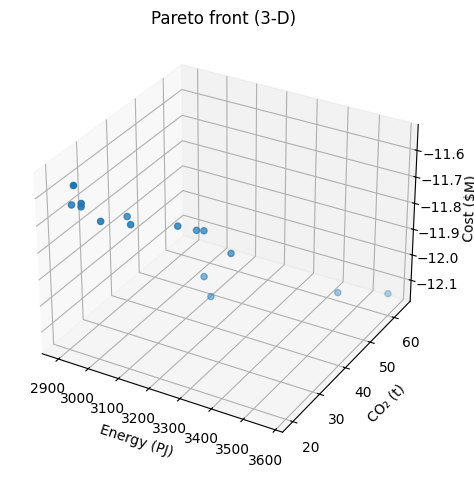

In [23]:
# ---------------------------------------------------------------------------
# 4.  Plot consensus cloud in objective space
# ---------------------------------------------------------------------------
if agree_F.empty:
    print("No policies meet the consensus threshold.")
else:
    plot_pareto(
        agree_F[["production_total", "emission_total", "technical_cost"]],
        labels=["Energy (PJ)", "CO₂ (t)", "Cost ($M)"],
    )


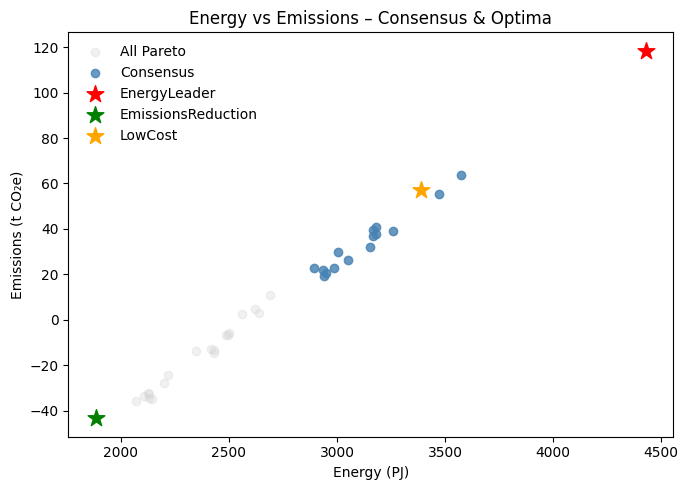

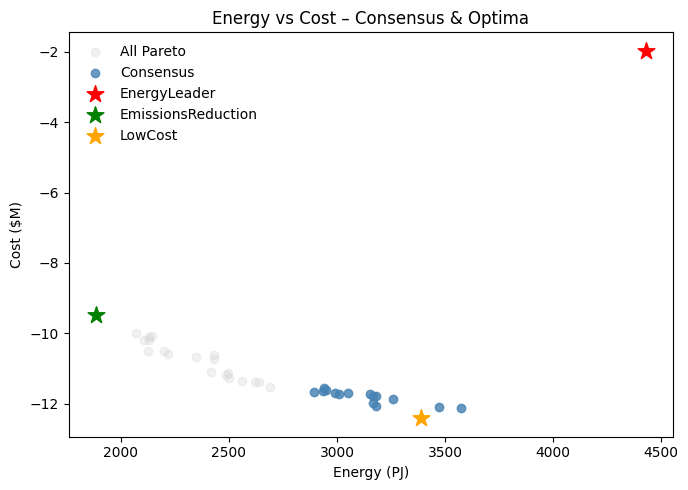

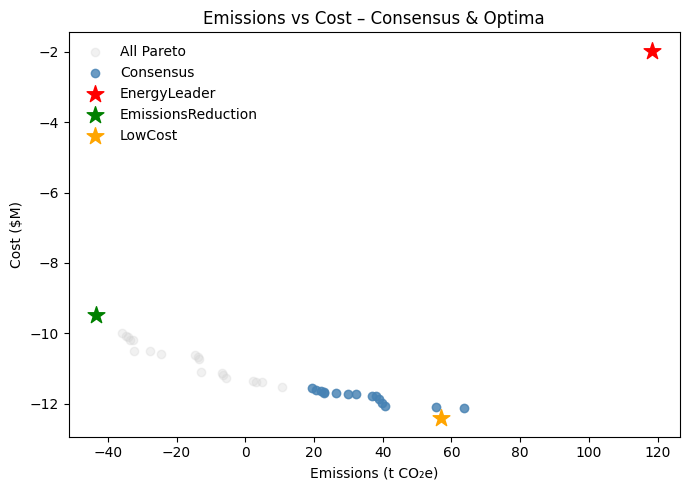

In [24]:

# ---------------------------------------------------------------------------
# 5.  Scatter every pair of metrics – Pareto vs consensus vs optima
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
from itertools import combinations

pairs = list(combinations(
    [("production_total", "Energy (PJ)"),
     ("emission_total",   "Emissions (t CO₂e)"),
     ("technical_cost",   "Cost ($M)")], 2))

col_opt_colour = {"EnergyLeader": "red",
                  "EmissionsReduction": "green",
                  "LowCost": "orange"}

best_pts = {n: pd.Series(scores[n]) for n in narratives_cfg}

for (mx, lx), (my, ly) in pairs:
    plt.figure(figsize=(7, 5))
    plt.scatter(pareto_F[mx], pareto_F[my],
                color="lightgrey", alpha=0.3, label="All Pareto")
    plt.scatter(agree_F[mx], agree_F[my],
                color="steelblue", alpha=0.8, label="Consensus")
    for n, s in best_pts.items():
        plt.scatter(s[mx], s[my],
                    color=col_opt_colour[n], marker="*", s=160, label=n)
    plt.xlabel(lx); plt.ylabel(ly)
    plt.title(f"{lx.split()[0]} vs {ly.split()[0]} – Consensus & Optima")
    plt.legend(frameon=False); plt.tight_layout(); plt.show()


### Visualise consensus vs. each narrative’s optimum for **every pair of metrics**

The loop below will create three separate scatter-plots:

1. Energy vs Emissions  
2. Energy vs Cost  
3. Cost vs Emissions

For each plot you’ll see  
* light-grey dots  = every Pareto policy  
* blue dots         = “agreement” policies (worst regret ≤ 20 %)  
* coloured ★ stars = the single-objective optimum for each narrative


#### additional note

The single-objective runs give you reference points only: the best value each narrative can dream of (“utopia”).
They do not give you a compromise solution.

The multi-objective run (NSGA-II) does something different:

**Explores all three metrics at once.** It searches for feature sets that cannot be improved in one metric without hurting at least one of the others.

Returns the whole Pareto front. This front contains every sensible trade-off between energy, emissions and cost—including points that sit between the three utopias.

**Feeds the regret screen.** You compute regret for every Pareto policy, then keep only those whose worst sacrifice is below your threshold. This “agreement area” is the practical middle ground where all narratives are satisfied.

**So: single-objective runs define the scoring yard-sticks; the multi-objective optimiser supplies the candidate policies from which you pick the mutually acceptable ones**